https://colab.research.google.com/drive/1ws3HoFRdVLsVo1Sk3FGZ8rIQ3Q8fq-es

1. Install & load packages

In [ ]:
# Install required packages
install.packages("ggplot2")
install.packages("dplyr")

# Load libraries
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




This loads ggplot2 for visualisation and dplyr for data manipulation, which are essential for analysing patterns in the dataset.

2. Load datasets

In [ ]:
# Base GitHub link
base_url <- "https://raw.githubusercontent.com/maazmohammed626-ctrl/northstar-database-analytics/refs/heads/main/northstar_dataset/"

# Load key datasets
orders <- read.csv(paste0(base_url, "orders.csv"))
deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
complaints <- read.csv(paste0(base_url, "complaints.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))
drivers <- read.csv(paste0(base_url, "drivers.csv"))

Datasets are loaded again in this notebook to perform analytical visualisation independently from SQL queries.

3. Service demand distribution

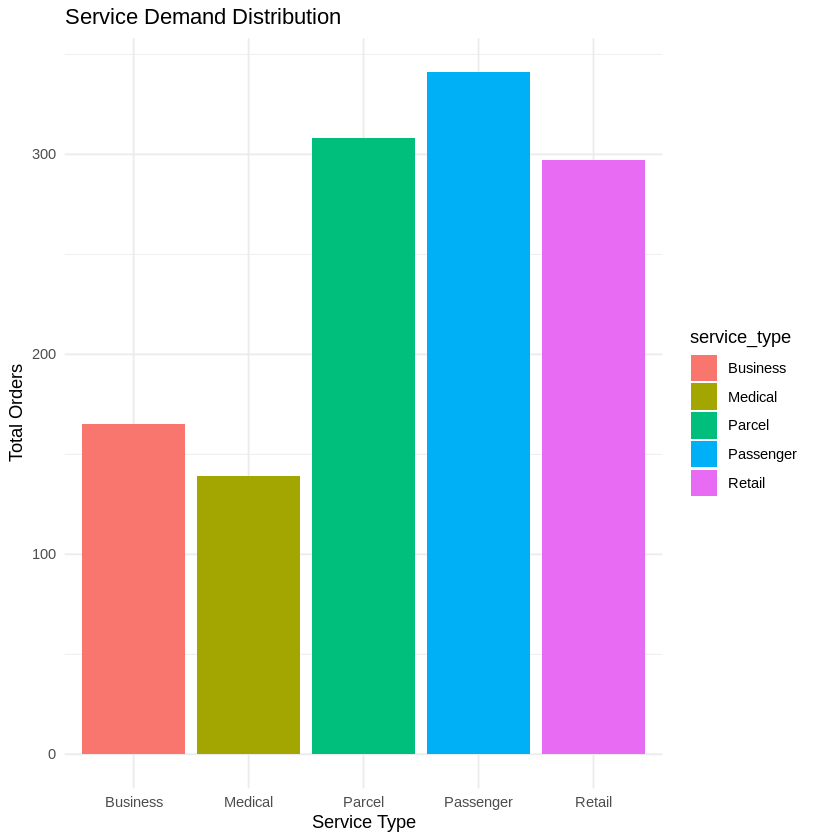

In [ ]:
# Count orders by service type
service_data <- orders %>%
  group_by(service_type) %>%
  summarise(total_orders = n())

# Plot
ggplot(service_data, aes(x = service_type, y = total_orders, fill = service_type)) +
  geom_bar(stat = "identity") +
  labs(title = "Service Demand Distribution",
       x = "Service Type",
       y = "Total Orders") +
  theme_minimal()

This chart shows how demand is distributed across different service types, helping identify which services dominate operational workload.

4. Delivery performance (status)

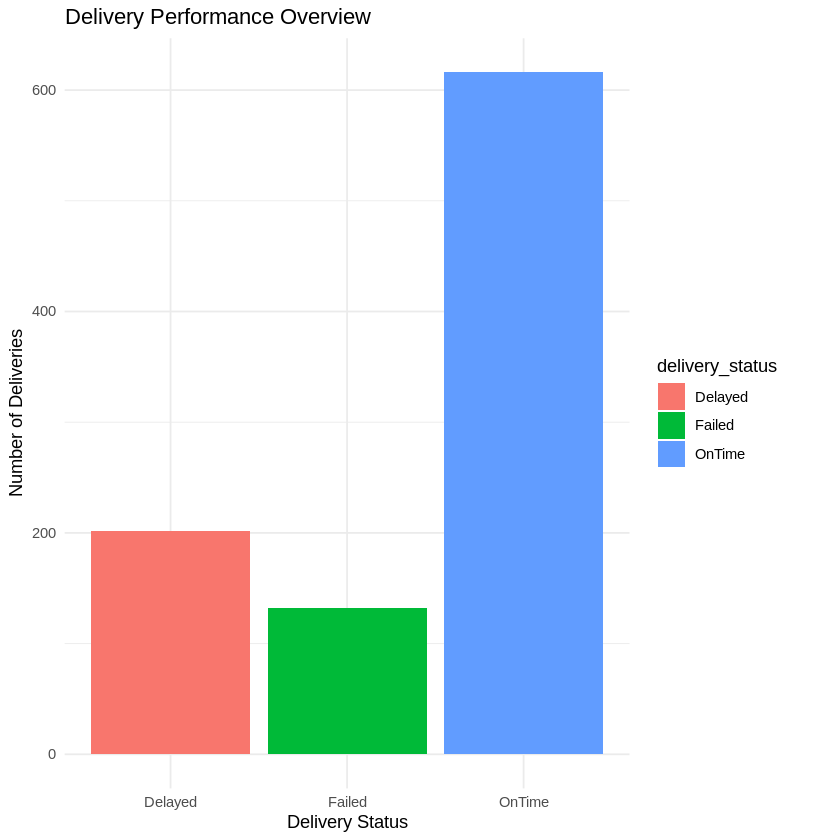

In [ ]:
# Count delivery status
delivery_data <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total = n())

# Plot
ggplot(delivery_data, aes(x = delivery_status, y = total, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(title = "Delivery Performance Overview",
       x = "Delivery Status",
       y = "Number of Deliveries") +
  theme_minimal()

This visualises delivery outcomes, allowing identification of delays and failures within operations.

5. Complaints severity distribution

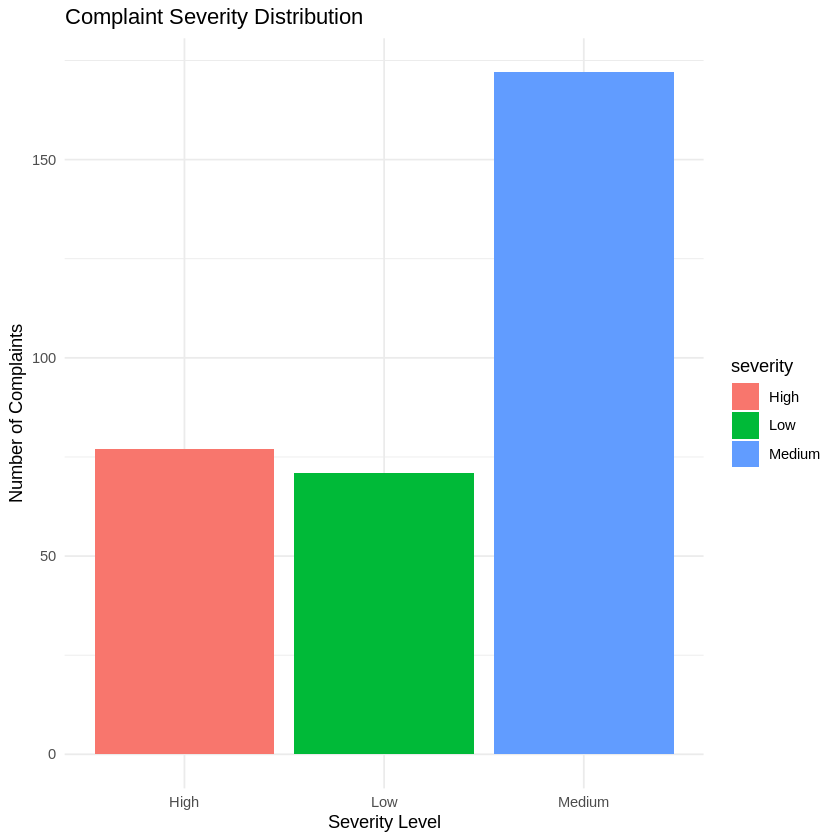

In [ ]:
# Count complaints by severity
complaint_data <- complaints %>%
  group_by(severity) %>%
  summarise(total = n())

# Plot
ggplot(complaint_data, aes(x = severity, y = total, fill = severity)) +
  geom_bar(stat = "identity") +
  labs(title = "Complaint Severity Distribution",
       x = "Severity Level",
       y = "Number of Complaints") +
  theme_minimal()

This chart shows how serious customer complaints are, helping assess service quality issues.

6. Hub performance by zone

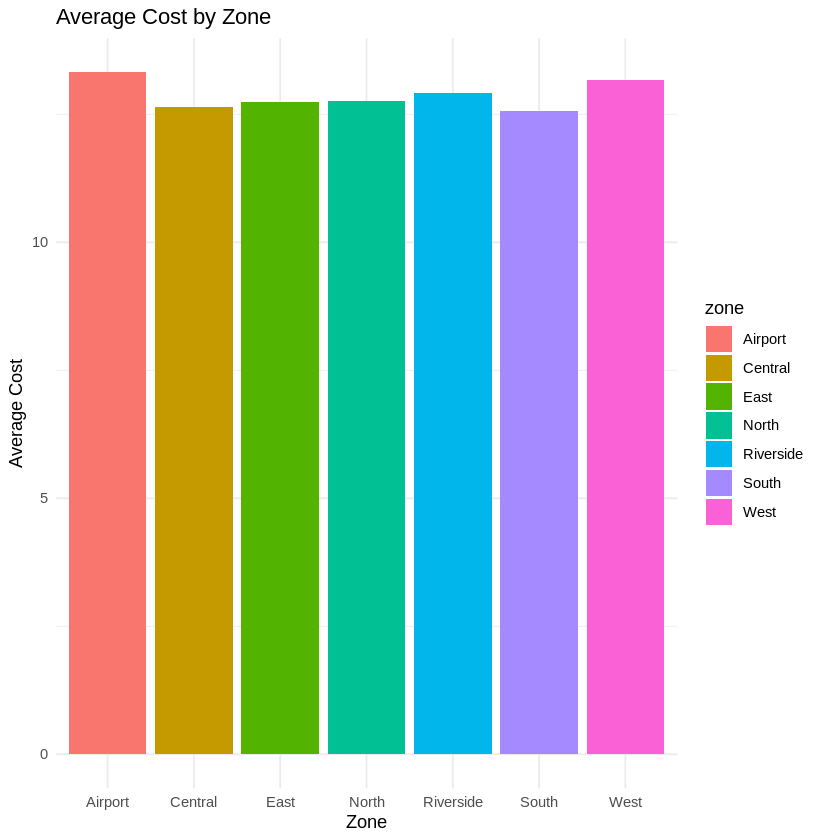

In [ ]:
# Merge deliveries and hubs
hub_data <- deliveries %>%
  inner_join(hubs, by = "hub_id") %>%
  group_by(zone) %>%
  summarise(avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
            avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE))

# Plot
ggplot(hub_data, aes(x = zone, y = avg_cost, fill = zone)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Cost by Zone",
       x = "Zone",
       y = "Average Cost") +
  theme_minimal()

This compares operational cost across zones, helping identify inefficient locations.

7. Driver performance vs rating

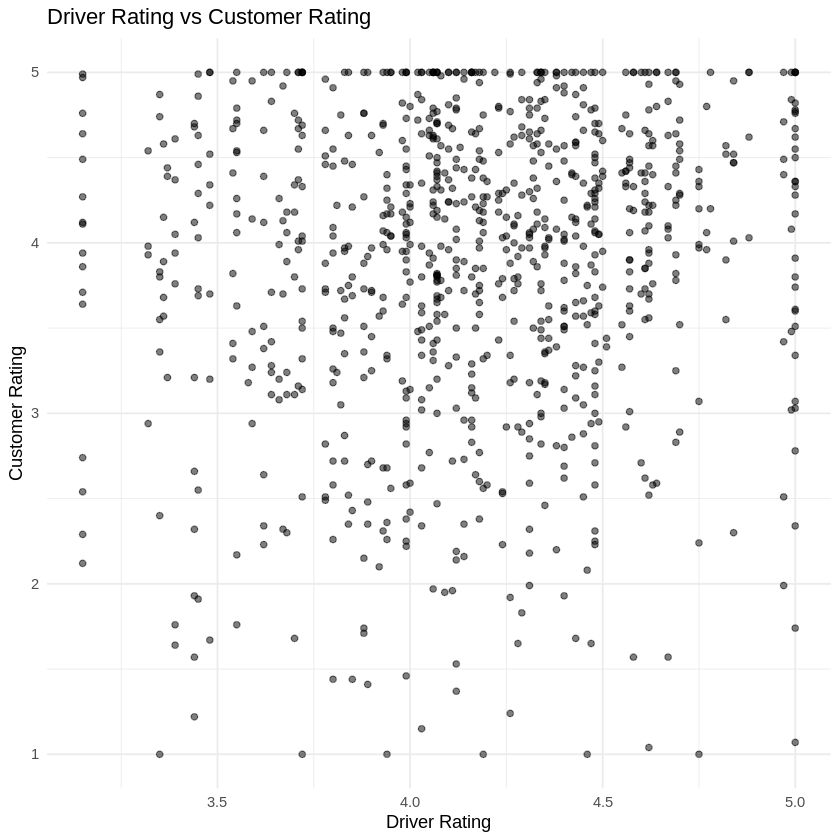

In [ ]:
# Remove rows with missing values before plotting
driver_data_clean <- driver_data %>%
  filter(!is.na(driver_rating), !is.na(customer_rating_post_delivery))

# Plot cleaned data
ggplot(driver_data_clean, aes(x = driver_rating, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.5) +
  labs(title = "Driver Rating vs Customer Rating",
       x = "Driver Rating",
       y = "Customer Rating") +
  theme_minimal()

Some rows with missing values were automatically removed during plotting. This reflects real-world data quality issues. To ensure accurate visualisation, records with missing values were filtered before analysis.

8. Route overrides vs rating

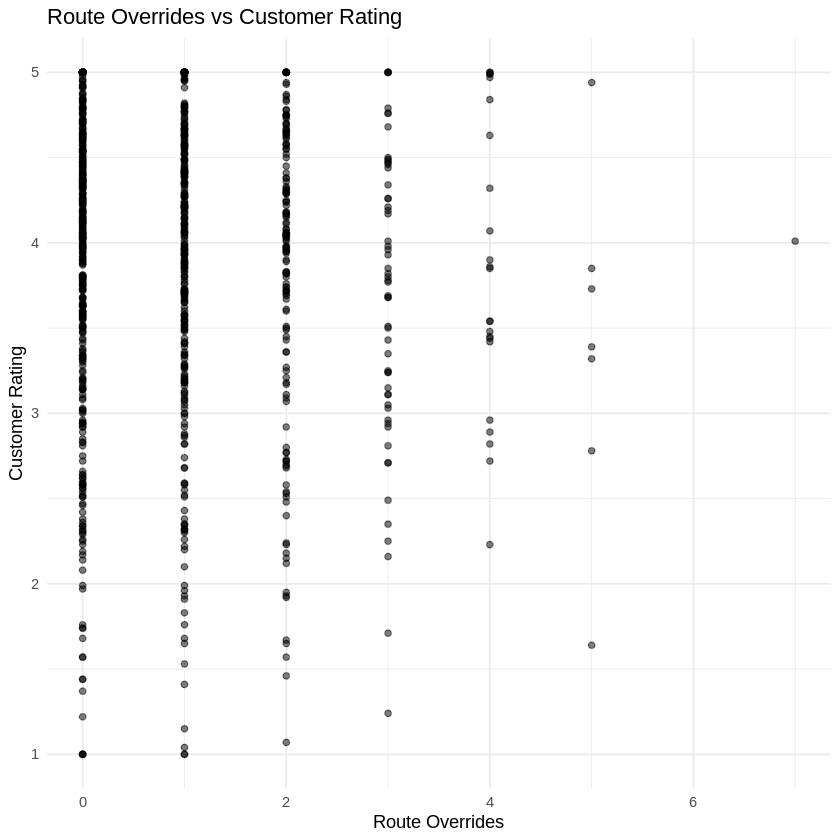

In [ ]:
# Clean data before plotting
deliveries_clean <- deliveries %>%
  filter(!is.na(manual_route_override_count),
         !is.na(customer_rating_post_delivery))

# Plot
ggplot(deliveries_clean, aes(x = manual_route_override_count,
                             y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.5) +
  labs(title = "Route Overrides vs Customer Rating",
       x = "Route Overrides",
       y = "Customer Rating") +
  theme_minimal()

Some records contained missing values in route override counts or customer ratings and were automatically excluded from the visualisation. These records were filtered to ensure accurate analysis. This highlights the presence of incomplete data within the dataset.